<!-- colab-badge-top -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/04b_lvk_blind_data_challenge_answer.ipynb)

# Instructor answer: blind LVK data challenge

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**


## Goal and route

Worked instructor analysis of the blind H1/L1 challenge.

> **Live route**
>
> Run the search and coincidence sections first; unblind only in the last section.


**Boundary:** The search statistic is illustrative and uncalibrated. The PE uses a restricted Newtonian-inspiral, fixed-response and fixed-mass-ratio model. Only chirp mass and coalescence time are sampled with fast workshop Dynesty settings.

## Data and supplied ranges

This answer deliberately follows the same order as the student worksheet.
The generating PSD and injection parameters are not read from the HDF5 file.

[Download the HDF5 data directly](../assets/lvk_blind_challenge.h5).

In [1]:
import os, sys, subprocess, importlib.util

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
missing = [
    package
    for package in ("corner", "h5py")
    if importlib.util.find_spec(package) is None
]
if missing:
    if IN_COLAB:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "corner>=2.2",
                "h5py>=3.11",
            ]
        )
    else:
        raise ImportError(
            "Install corner>=2.2 and h5py>=3.11, "
            "or use the locked workshop environment."
        )

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

import corner
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, find_peaks, sosfiltfilt, spectrogram, welch

plt.style.use("seaborn-v0_8-whitegrid")

local_candidates = [
    Path("assets/lvk_blind_challenge.h5"),
    Path("../assets/lvk_blind_challenge.h5"),
]
DATA_PATH = next(
    (path for path in local_candidates if path.exists()), local_candidates[0]
)
DATA_URL = (
    "https://raw.githubusercontent.com/nz-gravity/"
    "FQCP2026_GW_data_analysis/main/assets/lvk_blind_challenge.h5"
)
if not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    urlretrieve(DATA_URL, DATA_PATH)

with h5py.File(DATA_PATH, "r") as source:
    sampling_frequency = int(source.attrs["sampling_frequency_hz"])
    duration = float(source.attrs["duration_s"])
    start_time = float(source.attrs["start_time_s"])
    strain = {
        detector: np.asarray(source[f"strain/{detector}"][:], dtype=np.float64)
        for detector in ("H1", "L1")
    }

time = start_time + np.arange(len(strain["H1"])) / sampling_frequency
assert len(strain["H1"]) == len(strain["L1"]) == int(duration * sampling_frequency)
assert all(np.isfinite(values).all() for values in strain.values())
print(f"Loaded {duration:.0f} s at {sampling_frequency} Hz from {DATA_PATH}")
print("Detector arrays:", {name: values.shape for name, values in strain.items()})

Loaded 256 s at 1024 Hz from ../assets/lvk_blind_challenge.h5
Detector arrays: {'H1': (262144,), 'L1': (262144,)}


## 1. Inspect the data

The raw overview is a data-integrity check, not a detection plot.

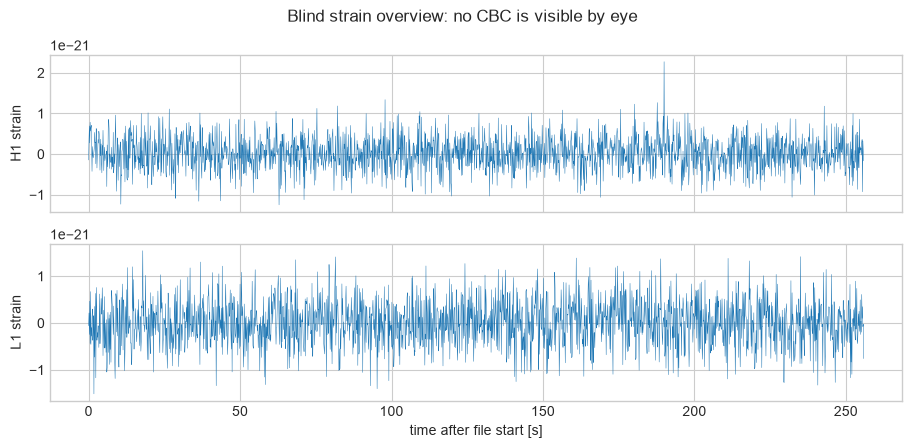

In [3]:
step = sampling_frequency // 8
fig, axes = plt.subplots(2, 1, figsize=(11, 4.5), sharex=True)
for axis, detector in zip(axes, ("H1", "L1")):
    axis.plot(time[::step], strain[detector][::step], lw=0.35)
    axis.set(ylabel=f"{detector} strain")
axes[-1].set_xlabel("time after file start [s]")
fig.suptitle("Blind strain overview: no CBC is visible by eye")
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-challenge-overview.png" alt="expected output: lvk-challenge-overview" style="max-width:100%">

</details>

## 2. Duration from the supplied prior

At leading order,

$$
t(f_\mathrm{low})=\frac{5}{256}
\left(\frac{G\mathcal M}{c^3}\right)^{-5/3}
(\pi f_\mathrm{low})^{-8/3}.
$$

The lower edge, not the unknown injected value, sets the longest template.

In [4]:
MTSUN_SI = 4.925490947e-6


def inspiral_time(chirp_mass, f_low=20.0):
    return 5 / 256 * (MTSUN_SI * chirp_mass) ** (-5 / 3) * (np.pi * f_low) ** (-8 / 3)


for label, lower_edge in (("bank A", 16.5), ("bank B", 26.6)):
    print(f"{label}: t20 at lower edge = {inspiral_time(lower_edge):.3f} s")
ANALYSIS_DURATION = 8.0
print("Use an 8 s PE segment: 6 s before and 2 s after coalescence.")

bank A: t20 at lower edge = 2.053 s
bank B: t20 at lower edge = 0.926 s
Use an 8 s PE segment: 6 s before and 2 s after coalescence.


## 3. Robust initial PSD

For discovery only, median Welch averaging over the full record is robust to a
few short signals/transients. After locating candidates we replace it with a
clean off-source estimate.

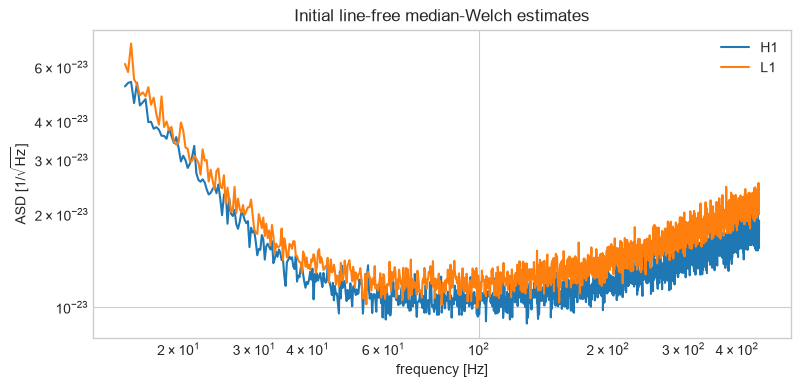

In [5]:
WELCH_SECONDS = 4


def median_welch(values):
    return welch(
        values,
        fs=sampling_frequency,
        window=("tukey", 0.2),
        nperseg=WELCH_SECONDS * sampling_frequency,
        noverlap=WELCH_SECONDS * sampling_frequency // 2,
        detrend=False,
        average="median",
    )


initial_psd = {detector: median_welch(values) for detector, values in strain.items()}
fig, ax = plt.subplots(figsize=(9, 4))
for detector, (frequency_welch, psd_welch) in initial_psd.items():
    usable = (frequency_welch >= 15) & (frequency_welch <= 450)
    ax.loglog(frequency_welch[usable], np.sqrt(psd_welch[usable]), label=detector)
ax.set(
    xlabel="frequency [Hz]",
    ylabel=r"ASD [1/$\sqrt{\mathrm{Hz}}$]",
    title="Initial line-free median-Welch estimates",
)
ax.legend()
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-challenge-initial-psd.png" alt="expected output: lvk-challenge-initial-psd" style="max-width:100%">

</details>

## 4. Coarse matched-filter search

We use a single representative mass ratio, $q=0.9$, and maximise over the
listed chirp masses. The template is the Newtonian stationary-phase inspiral

$$
\tilde h(f)\propto f^{-7/6}\exp\left[i\left(-\frac{\pi}{4}
+\frac{3}{128}(\pi\mathcal M_{\rm sec}f)^{-5/3}-2\pi f t_c\right)\right],
$$

with a smooth taper at the mass-dependent ISCO. Chirp mass and time therefore
retain their physical meanings, but merger/ringdown and higher-order phase are
absent. This is enough to locate the controlled signals; it is not a production
template bank, realistic LVK BBH model, or calibrated search.

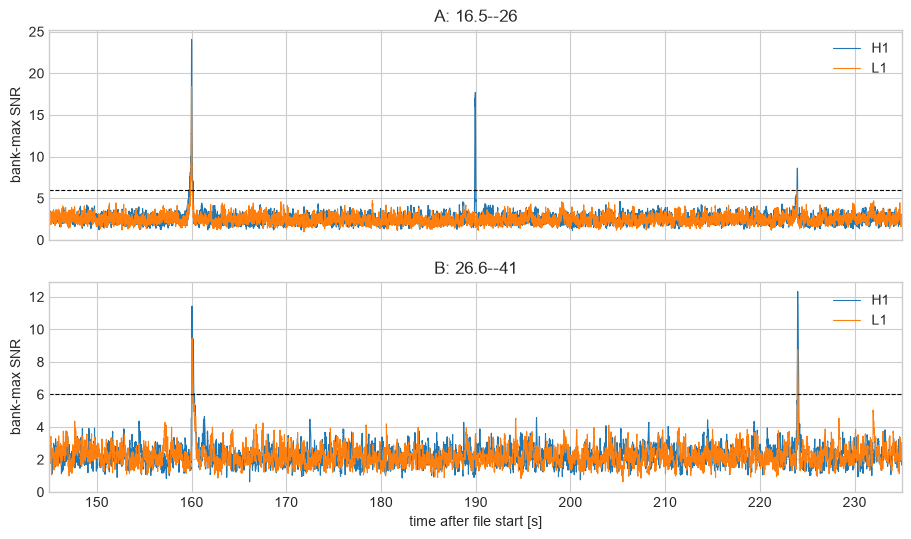

In [6]:
n_samples = len(time)
frequency = np.fft.rfftfreq(n_samples, 1 / sampling_frequency)
frequency_spacing = 1 / duration
data_frequency = {
    detector: np.fft.rfft(values) / sampling_frequency
    for detector, values in strain.items()
}
psd_on_search_grid = {
    detector: np.interp(frequency, *initial_psd[detector]) for detector in ("H1", "L1")
}

MTSUN_SI = 4.925490947e-6


def component_masses(chirp_mass, mass_ratio):
    eta = mass_ratio / (1 + mass_ratio) ** 2
    total_mass = chirp_mass / eta ** (3 / 5)
    primary_mass = total_mass / (1 + mass_ratio)
    return primary_mass, mass_ratio * primary_mass


def newtonian_chirp(frequency_array, chirp_mass, mass_ratio, coalescence_time=0.0):
    """Newtonian SPA inspiral with an explicit smooth ISCO cutoff."""
    waveform = np.zeros(frequency_array.size, dtype=complex)
    primary_mass, secondary_mass = component_masses(chirp_mass, mass_ratio)
    f_isco = 1 / (6**1.5 * np.pi * MTSUN_SI * (primary_mass + secondary_mass))
    taper_start = 0.85 * f_isco
    usable = (frequency_array >= 20.0) & (frequency_array < f_isco)
    taper = np.ones(frequency_array.size)
    taper_region = (frequency_array >= taper_start) & (frequency_array < f_isco)
    taper[taper_region] = 0.5 * (
        1
        + np.cos(
            np.pi
            * (frequency_array[taper_region] - taper_start)
            / (f_isco - taper_start)
        )
    )
    phase = (
        -np.pi / 4
        + 3
        / 128
        * (np.pi * MTSUN_SI * chirp_mass * frequency_array[usable]) ** (-5 / 3)
        - 2 * np.pi * frequency_array[usable] * coalescence_time
    )
    waveform[usable] = (
        frequency_array[usable] ** (-7 / 6) * taper[usable] * np.exp(1j * phase)
    )
    return waveform


def matched_filter_snr(data_fd, template_fd, psd):
    usable = (frequency >= 20) & (frequency <= 400) & np.isfinite(psd) & (psd > 0)
    integrand = np.zeros(frequency.size, dtype=complex)
    integrand[usable] = data_fd[usable] * np.conj(template_fd[usable]) / psd[usable]
    padded = np.zeros(n_samples, dtype=complex)
    padded[: frequency.size] = integrand
    correlation = 4 * frequency_spacing * n_samples * np.fft.ifft(padded)
    norm = np.sqrt(
        4 * frequency_spacing * np.sum(np.abs(template_fd[usable]) ** 2 / psd[usable])
    )
    return np.abs(correlation) / norm


banks = {
    "A: 16.5--26": np.linspace(16.5, 26.0, 20),
    "B: 26.6--41": np.linspace(26.6, 41.0, 24),
}
search_snr = {
    bank_name: {detector: np.zeros(n_samples) for detector in ("H1", "L1")}
    for bank_name in banks
}
best_mass = {
    bank_name: {detector: np.zeros(n_samples) for detector in ("H1", "L1")}
    for bank_name in banks
}
for bank_name, chirp_masses in banks.items():
    for chirp_mass in chirp_masses:
        template = newtonian_chirp(frequency, chirp_mass, mass_ratio=0.9)
        for detector in ("H1", "L1"):
            trial = matched_filter_snr(
                data_frequency[detector], template, psd_on_search_grid[detector]
            )
            better = trial > search_snr[bank_name][detector]
            search_snr[bank_name][detector][better] = trial[better]
            best_mass[bank_name][detector][better] = chirp_mass

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for axis, bank_name in zip(axes, banks):
    for detector in ("H1", "L1"):
        axis.plot(time, search_snr[bank_name][detector], lw=0.8, label=detector)
    axis.axhline(6, color="k", ls="--", lw=0.8)
    axis.set(ylabel="bank-max SNR", title=bank_name, xlim=(145, 235), ylim=(0, None))
    axis.legend()
axes[-1].set_xlabel("time after file start [s]")
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-challenge-search.png" alt="expected output: lvk-challenge-search" style="max-width:100%">

</details>

## 5. Coincidence and the glitch

A loud H1 trigger near 190 s lacks an L1 partner. Both banks instead contain
time-consistent H1/L1 peaks near the two CBC candidates. A 20 ms window is
generous relative to the inter-site light-travel time.

In [7]:
SNR_THRESHOLD = 6.0
COINCIDENCE_WINDOW = 0.020
DETECTOR_DELAYS = {"H1": 0.004, "L1": -0.006}
peak_tables = {}
coincident_candidates = []
for bank_name in banks:
    peak_tables[bank_name] = {}
    for detector in ("H1", "L1"):
        peaks, properties = find_peaks(
            search_snr[bank_name][detector],
            height=SNR_THRESHOLD,
            distance=int(0.5 * sampling_frequency),
        )
        peak_tables[bank_name][detector] = peaks
        print(f"\n{bank_name} {detector} peaks")
        for peak in peaks:
            print(
                f"  t={time[peak]:8.3f} s  rho={search_snr[bank_name][detector][peak]:5.1f}  "
                f"Mc~{best_mass[bank_name][detector][peak]:5.1f}"
            )
    for h1_peak in peak_tables[bank_name]["H1"]:
        separations = np.abs(time[peak_tables[bank_name]["L1"]] - time[h1_peak])
        if len(separations) and separations.min() <= COINCIDENCE_WINDOW:
            l1_peak = peak_tables[bank_name]["L1"][np.argmin(separations)]
            h1_geocent_time = time[h1_peak] - DETECTOR_DELAYS["H1"]
            l1_geocent_time = time[l1_peak] - DETECTOR_DELAYS["L1"]
            geocent_guess = 0.5 * (h1_geocent_time + l1_geocent_time)
            coincident_candidates.append((bank_name, geocent_guess, h1_peak, l1_peak))

print("\nCoincident candidates")
for bank_name, candidate_time, h1_peak, l1_peak in coincident_candidates:
    print(
        f"  {bank_name}: t~{candidate_time:.3f} s, "
        f"H1/L1 SNR={search_snr[bank_name]['H1'][h1_peak]:.1f}/"
        f"{search_snr[bank_name]['L1'][l1_peak]:.1f}"
    )

# One physical event can trigger both coarse banks. Cluster coincidences in
# time, then retain the bank with the larger quadrature-summed detector SNR.
unique_candidates = []
for candidate in sorted(coincident_candidates, key=lambda item: item[1]):
    bank_name, candidate_time, h1_peak, l1_peak = candidate
    rank = np.hypot(
        search_snr[bank_name]["H1"][h1_peak],
        search_snr[bank_name]["L1"][l1_peak],
    )
    if unique_candidates and abs(candidate_time - unique_candidates[-1][1]) < 0.2:
        if rank > unique_candidates[-1][-1]:
            unique_candidates[-1] = (*candidate, rank)
    else:
        unique_candidates.append((*candidate, rank))

print("\nTwo time-clustered candidates")
for bank_name, candidate_time, h1_peak, l1_peak, rank in unique_candidates:
    print(f"  {bank_name}: t~{candidate_time:.3f} s, network rank={rank:.1f}")


A: 16.5--26 H1 peaks
  t= 160.003 s  rho= 24.0  Mc~ 22.0
  t= 189.959 s  rho= 17.7  Mc~ 21.0
  t= 223.958 s  rho=  8.6  Mc~ 24.5

A: 16.5--26 L1 peaks
  t= 159.994 s  rho= 18.4  Mc~ 22.0
  t= 223.949 s  rho=  6.0  Mc~ 26.0

B: 26.6--41 H1 peaks
  t= 160.048 s  rho= 11.4  Mc~ 26.6
  t= 223.994 s  rho= 12.3  Mc~ 30.4

B: 26.6--41 L1 peaks
  t= 160.068 s  rho=  9.4  Mc~ 31.6
  t= 223.992 s  rho=  8.8  Mc~ 30.4

Coincident candidates
  A: 16.5--26: t~160.000 s, H1/L1 SNR=24.0/18.4
  A: 16.5--26: t~223.955 s, H1/L1 SNR=8.6/6.0
  B: 26.6--41: t~223.994 s, H1/L1 SNR=12.3/8.8

Two time-clustered candidates
  A: 16.5--26: t~160.000 s, network rank=30.3
  B: 26.6--41: t~223.994 s, network rank=15.1


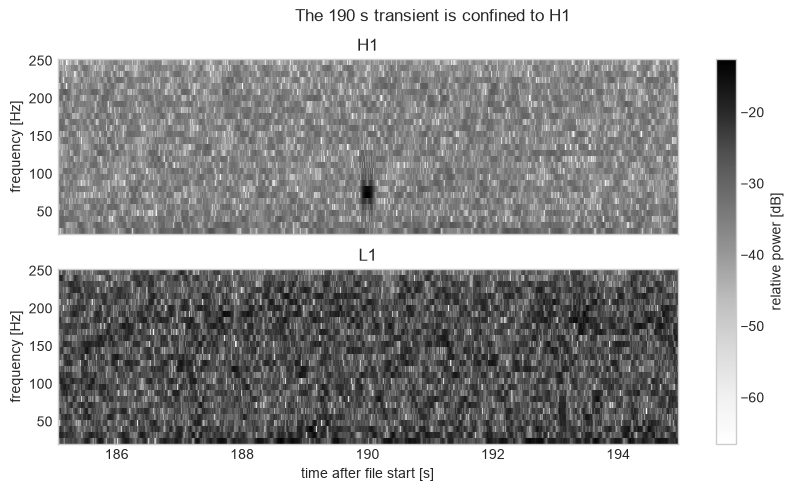

In [8]:
transient_window = (time >= 185) & (time <= 195)
sos = butter(4, (20, 250), btype="bandpass", fs=sampling_frequency, output="sos")
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, sharey=True)
for axis, detector in zip(axes, ("H1", "L1")):
    filtered = sosfiltfilt(sos, strain[detector][transient_window])
    filtered /= np.std(filtered)
    spec_frequency, spec_time, power = spectrogram(
        filtered,
        fs=sampling_frequency,
        window=("tukey", 0.2),
        nperseg=128,
        noverlap=112,
        mode="psd",
    )
    band = (spec_frequency >= 20) & (spec_frequency <= 250)
    image = axis.pcolormesh(
        185 + spec_time,
        spec_frequency[band],
        10 * np.log10(power[band] + 1e-12),
        shading="auto",
    )
    axis.set(ylabel="frequency [Hz]", title=detector)
axes[-1].set_xlabel("time after file start [s]")
fig.colorbar(image, ax=axes, label="relative power [dB]")
fig.suptitle("The 190 s transient is confined to H1")
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-challenge-glitch.png" alt="expected output: lvk-challenge-glitch" style="max-width:100%">

</details>

The answer is to veto the short interval around 190 s from this
search and exclude it from PSD estimation. Because it is far from both event
segments, no subtraction is needed. If continuous filtering through the
interval were required, use a tapered gate or validated inpainting rather than
an abrupt rectangular zero.

## 6. Final off-source Welch PSDs

The first 128 seconds are clean and precede the earliest candidate by more than
the allowed waveform duration. Four-second, 50%-overlapped segments give 63
median-averaged periodograms per detector.

clean duration: 128.0 s
overlapping periodograms: 63


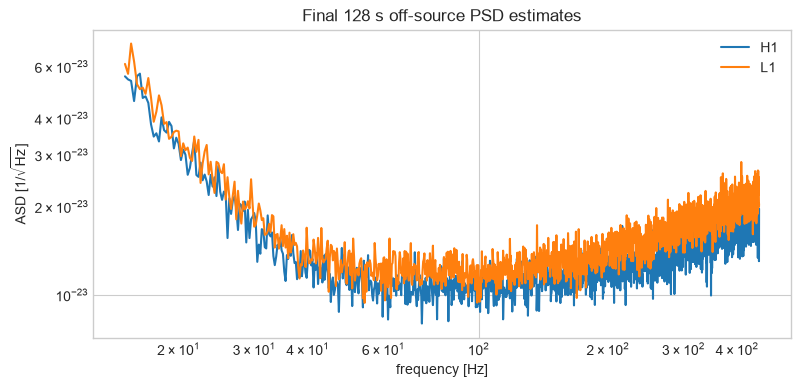

In [9]:
clean = time < 128.0
final_psd = {
    detector: median_welch(values[clean]) for detector, values in strain.items()
}
number_of_averages = 1 + (clean.sum() - 4 * sampling_frequency) // (
    2 * sampling_frequency
)
print("clean duration:", clean.sum() / sampling_frequency, "s")
print("overlapping periodograms:", number_of_averages)

fig, ax = plt.subplots(figsize=(9, 4))
for detector, (frequency_welch, psd_welch) in final_psd.items():
    usable = (frequency_welch >= 15) & (frequency_welch <= 450)
    ax.loglog(frequency_welch[usable], np.sqrt(psd_welch[usable]), label=detector)
ax.set(
    xlabel="frequency [Hz]",
    ylabel=r"ASD [1/$\sqrt{\mathrm{Hz}}$]",
    title="Final 128 s off-source PSD estimates",
)
ax.legend()
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-challenge-final-psd.png" alt="expected output: lvk-challenge-final-psd" style="max-width:100%">

</details>

## 7. Restricted priors and likelihoods

For workshop speed, the response, mass ratio, zero spins, amplitude (hence
distance), and phase are supplied and fixed. We sample only chirp mass and
geocentric time with an ordinary Gaussian-noise likelihood. This is a proper
two-parameter posterior **conditional on those known quantities**, not a full
CBC posterior. An actual LVK analysis would infer distance, orientation, phase,
calibration, and waveform systematics.

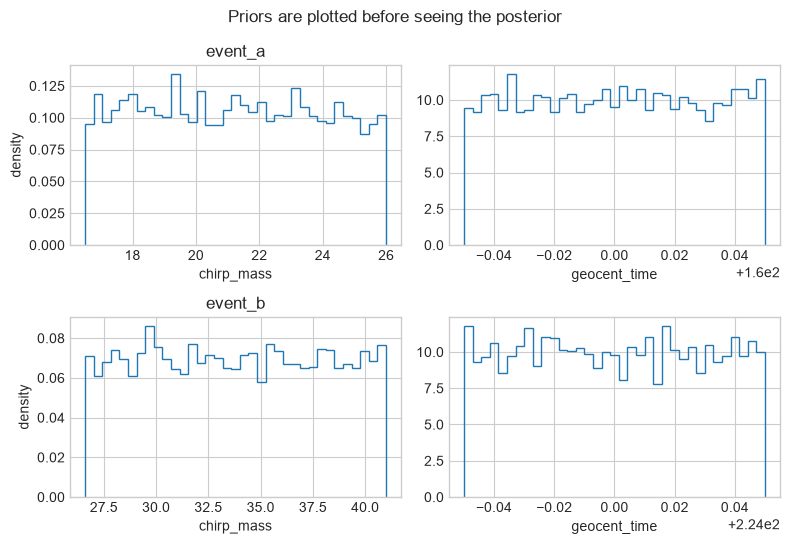

In [10]:
KNOWN_RESPONSE = {
    "H1": dict(gain=1.0 + 0.0j, delay=DETECTOR_DELAYS["H1"]),
    "L1": dict(gain=0.82 * np.exp(0.35j), delay=DETECTOR_DELAYS["L1"]),
}
candidate_specs = [
    dict(
        label="event_a",
        time=160.0,
        chirp_bounds=(16.5, 26.0),
        mass_ratio=0.85,
        amplitude=1.7273387669253173e-21,
        phase=0.0,
        search_mass=22.0,
    ),
    dict(
        label="event_b",
        time=224.0,
        chirp_bounds=(26.6, 41.0),
        mass_ratio=1.00,
        amplitude=9.826371643184475e-22,
        phase=0.0,
        search_mass=31.0,
    ),
]


challenge_priors = {
    spec["label"]: dict(
        chirp_mass=spec["chirp_bounds"],
        geocent_time=(spec["time"] - 0.05, spec["time"] + 0.05),
    )
    for spec in candidate_specs
}
prior_rng = np.random.default_rng(20260830)
fig, axes = plt.subplots(2, 2, figsize=(8, 5.5))
for row, spec in enumerate(candidate_specs):
    draws = {
        parameter: prior_rng.uniform(*bounds, 4000)
        for parameter, bounds in challenge_priors[spec["label"]].items()
    }
    for axis, parameter in zip(axes[row], ("chirp_mass", "geocent_time")):
        axis.hist(draws[parameter], bins=35, density=True, histtype="step")
        axis.set(
            xlabel=parameter, ylabel="density" if parameter == "chirp_mass" else None
        )
    axes[row, 0].set_title(spec["label"])
fig.suptitle("Priors are plotted before seeing the posterior")
fig.tight_layout()
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-challenge-priors.png" alt="expected output: lvk-challenge-priors" style="max-width:100%">

</details>

In [11]:
PE_DURATION = 8.0


class TwoParameterCBCLikelihood:
    """Toy network likelihood in chirp mass and geocentric time only."""

    def __init__(self, specification):
        self.parameters = {"chirp_mass": None, "geocent_time": None}
        self.specification = specification
        self.segment_start = specification["time"] - 6.0
        first = int(round((self.segment_start - start_time) * sampling_frequency))
        count = int(PE_DURATION * sampling_frequency)
        self.frequency = np.fft.rfftfreq(count, 1 / sampling_frequency)
        self.frequency_spacing = 1 / PE_DURATION
        self.data_frequency = {
            detector: np.fft.rfft(strain[detector][first : first + count])
            / sampling_frequency
            for detector in ("H1", "L1")
        }
        self.psd = {
            detector: np.interp(self.frequency, *final_psd[detector])
            for detector in ("H1", "L1")
        }
        self.usable = (self.frequency >= 20) & (self.frequency <= 400)

    def detector_templates(self, parameters):
        local_geocent_time = parameters["geocent_time"] - self.segment_start
        return {
            detector: self.specification["amplitude"]
            * np.exp(1j * self.specification["phase"])
            * response["gain"]
            * newtonian_chirp(
                self.frequency,
                parameters["chirp_mass"],
                self.specification["mass_ratio"],
                local_geocent_time + response["delay"],
            )
            for detector, response in KNOWN_RESPONSE.items()
        }

    def network_statistics(self, parameters):
        templates = self.detector_templates(parameters)
        overlap = 0.0
        norm = 0.0
        for detector, template in templates.items():
            overlap += (
                4
                * self.frequency_spacing
                * np.real(
                    np.sum(
                        np.conj(template[self.usable])
                        * self.data_frequency[detector][self.usable]
                        / self.psd[detector][self.usable]
                    )
                )
            )
            norm += (
                4
                * self.frequency_spacing
                * np.sum(
                    np.abs(template[self.usable]) ** 2 / self.psd[detector][self.usable]
                )
            )
        return overlap, norm, templates

    def log_likelihood(self):
        overlap, norm, _ = self.network_statistics(self.parameters)
        if not np.isfinite(norm) or norm <= 0:
            return -np.inf
        # The data-only Gaussian normalisation is constant in (Mc, tc), so the
        # likelihood ratio is (d|h) - 1/2 (h|h).
        return float(overlap - 0.5 * norm)


challenge_likelihoods = {
    spec["label"]: TwoParameterCBCLikelihood(spec) for spec in candidate_specs
}
print("Built two independent two-parameter toy likelihoods.")

Built two independent two-parameter toy likelihoods.


## 8. Run a two-dimensional Metropolis sampler

Two independent random-walk chains sample only $(\mathcal M,t_c)$. The coarse
matched-filter estimates from Section 4 supply the starting masses. This matters
because fixing phase makes the likelihood much narrower than the phase-maximised
search statistic. Acceptance fractions and trace agreement are required checks;
this short classroom run is not an evidence calculation.

In [12]:
sampler_rng = np.random.default_rng(20260831)
challenge_chains = {}
challenge_samples = {}


def log_posterior(likelihood, specification, state):
    chirp_mass, geocent_time = state
    low, high = specification["chirp_bounds"]
    if not (low <= chirp_mass <= high):
        return -np.inf
    if not (
        specification["time"] - 0.05 <= geocent_time <= specification["time"] + 0.05
    ):
        return -np.inf
    likelihood.parameters.update(
        chirp_mass=float(chirp_mass), geocent_time=float(geocent_time)
    )
    return likelihood.log_likelihood()


for spec in candidate_specs:
    label = spec["label"]
    likelihood = challenge_likelihoods[label]
    seed = np.array([spec["search_mass"], spec["time"]])
    proposal_scale = np.array(
        [
            0.025 if label == "event_a" else 0.06,
            0.00025,
        ]
    )
    event_chains = []
    for chain_index in range(2):
        state = seed + sampler_rng.normal(scale=0.2 * proposal_scale)
        state[0] = np.clip(state[0], *spec["chirp_bounds"])
        state[1] = np.clip(state[1], spec["time"] - 0.05, spec["time"] + 0.05)
        current_logp = log_posterior(likelihood, spec, state)
        chain = np.empty((6000, 2))
        accepted = 0
        for step_index in range(len(chain)):
            proposal = state + sampler_rng.normal(scale=proposal_scale)
            proposal_logp = log_posterior(likelihood, spec, proposal)
            if np.log(sampler_rng.random()) < proposal_logp - current_logp:
                state, current_logp = proposal, proposal_logp
                accepted += 1
            chain[step_index] = state
        print(label, "chain", chain_index + 1, "acceptance", accepted / len(chain))
        event_chains.append(chain)
    challenge_chains[label] = event_chains
    challenge_samples[label] = np.concatenate([chain[1000:] for chain in event_chains])
    print(label, "retained samples:", len(challenge_samples[label]))

event_a chain 1 acceptance 0.2881666666666667


event_a chain 2 acceptance 0.2783333333333333
event_a retained samples: 10000


event_b chain 1 acceptance 0.572


event_b chain 2 acceptance 0.5615
event_b retained samples: 10000



event_a
  chirp_mass                22.031 [   22.008,    22.055]
  geocent_time             160.000 [  160.000,   160.000]


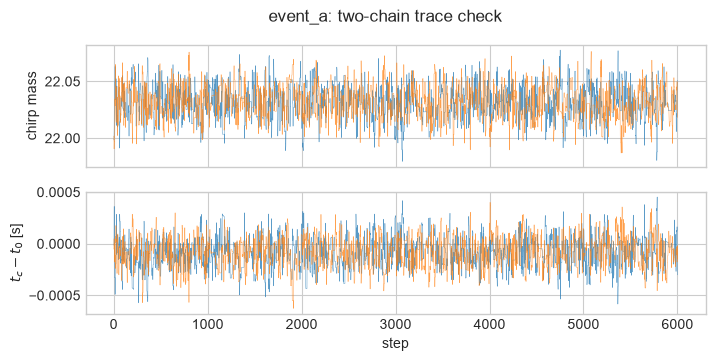


event_b
  chirp_mass                31.052 [   30.916,    31.193]
  geocent_time             224.000 [  223.999,   224.001]


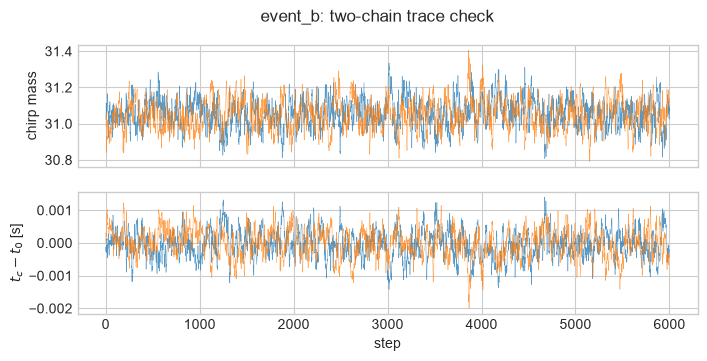

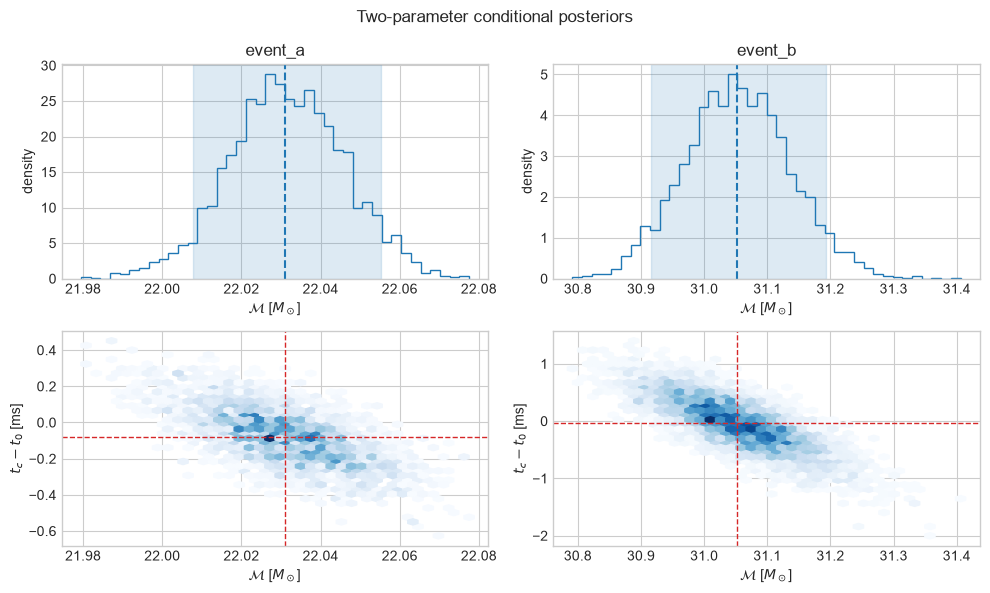

In [13]:
posterior_parameters = ["chirp_mass", "geocent_time"]
for spec in candidate_specs:
    label = spec["label"]
    posterior = challenge_samples[label]
    print(f"\n{label}")
    for column, parameter in enumerate(posterior_parameters):
        low, median, high = np.quantile(posterior[:, column], [0.05, 0.5, 0.95])
        print(f"  {parameter:22s} {median:9.3f} [{low:9.3f}, {high:9.3f}]")
    fig, trace_axes = plt.subplots(2, 1, figsize=(8, 3.5), sharex=True)
    for chain in challenge_chains[label]:
        trace_axes[0].plot(chain[:, 0], lw=0.35, alpha=0.75)
        trace_axes[1].plot(chain[:, 1] - spec["time"], lw=0.35, alpha=0.75)
    trace_axes[0].set(ylabel="chirp mass")
    trace_axes[1].set(xlabel="step", ylabel=r"$t_c-t_0$ [s]")
    fig.suptitle(f"{label}: two-chain trace check")
    plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for column, spec in enumerate(candidate_specs):
    label = spec["label"]
    posterior = challenge_samples[label]
    mass_quantiles = np.quantile(posterior[:, 0], [0.05, 0.5, 0.95])
    time_offsets_ms = 1000 * (posterior[:, 1] - spec["time"])
    time_quantiles = np.quantile(time_offsets_ms, [0.05, 0.5, 0.95])
    axes[0, column].hist(posterior[:, 0], bins=40, density=True, histtype="step")
    axes[0, column].axvspan(
        mass_quantiles[0], mass_quantiles[2], color="C0", alpha=0.15
    )
    axes[0, column].axvline(mass_quantiles[1], color="C0", ls="--")
    axes[0, column].set(
        xlabel=r"$\mathcal{M}$ [$M_\odot$]", ylabel="density", title=label
    )
    axes[1, column].hexbin(
        posterior[:, 0], time_offsets_ms, gridsize=38, mincnt=1, cmap="Blues"
    )
    axes[1, column].axvline(mass_quantiles[1], color="C3", ls="--", lw=1)
    axes[1, column].axhline(time_quantiles[1], color="C3", ls="--", lw=1)
    axes[1, column].set(
        xlabel=r"$\mathcal{M}$ [$M_\odot$]",
        ylabel=r"$t_c-t_0$ [ms]",
    )
fig.suptitle("Two-parameter conditional posteriors")
fig.tight_layout()
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-challenge-posteriors.png" alt="expected output: lvk-challenge-posteriors" style="max-width:100%">

</details>

## 9. Waveform and residual checks

The posterior median should explain coherent power in both detectors. A corner
plot alone does not test whether a CBC waveform actually removed the candidate.

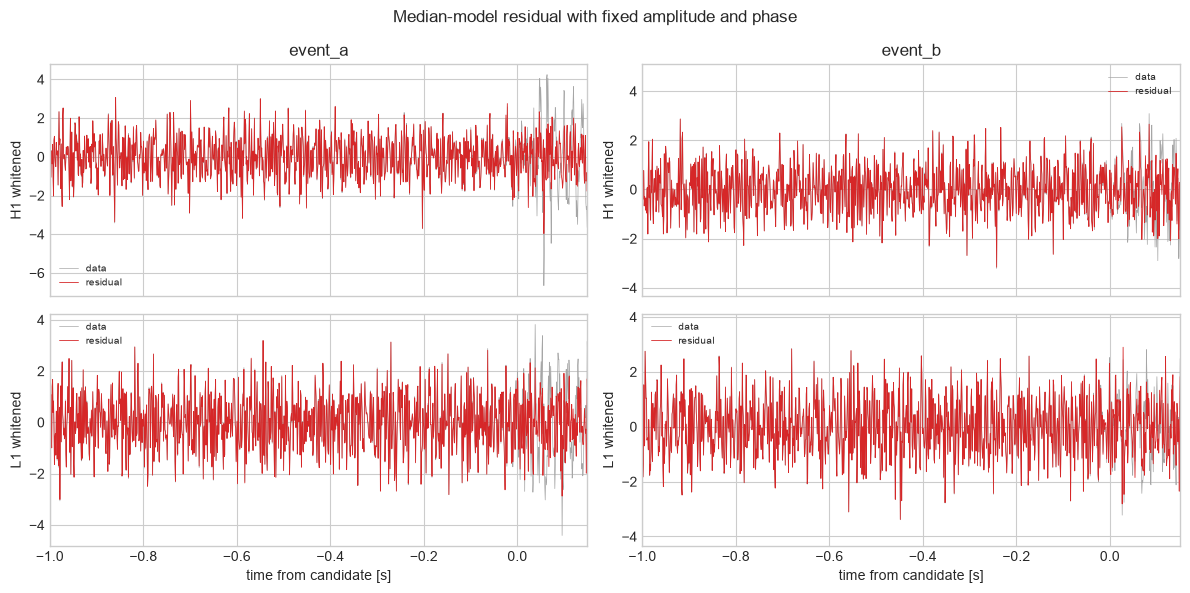

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex="col")
for column, spec in enumerate(candidate_specs):
    label = spec["label"]
    posterior = challenge_samples[label]
    median_parameters = dict(zip(posterior_parameters, np.median(posterior, axis=0)))
    likelihood = challenge_likelihoods[label]
    overlap, norm, templates = likelihood.network_statistics(median_parameters)
    for row, detector in enumerate(("H1", "L1")):
        model = templates[detector]
        residual = likelihood.data_frequency[detector] - model
        usable = likelihood.usable
        psd = likelihood.psd[detector]
        whitened_data_fd = np.zeros_like(likelihood.data_frequency[detector])
        whitened_residual_fd = np.zeros_like(residual)
        whitened_data_fd[usable] = likelihood.data_frequency[detector][
            usable
        ] / np.sqrt(psd[usable])
        whitened_residual_fd[usable] = residual[usable] / np.sqrt(psd[usable])
        whitened_data = np.fft.irfft(
            whitened_data_fd, n=int(PE_DURATION * sampling_frequency)
        )
        whitened_residual = np.fft.irfft(
            whitened_residual_fd, n=int(PE_DURATION * sampling_frequency)
        )
        reference_scale = np.std(whitened_data[: 3 * sampling_frequency])
        whitened_data /= reference_scale
        whitened_residual /= reference_scale
        local_time = np.arange(len(whitened_data)) / sampling_frequency - 6
        axes[row, column].plot(
            local_time, whitened_data, color="0.65", lw=0.5, label="data"
        )
        axes[row, column].plot(
            local_time,
            whitened_residual,
            color="C3",
            lw=0.6,
            label="residual",
        )
        axes[row, column].set(
            xlim=(-1.0, 0.15),
            ylabel=f"{detector} whitened",
            title=label if row == 0 else None,
        )
        axes[row, column].legend(fontsize=7)
axes[-1, 0].set_xlabel("time from candidate [s]")
axes[-1, 1].set_xlabel("time from candidate [s]")
fig.suptitle("Median-model residual with fixed amplitude and phase")
fig.tight_layout()
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-challenge-residuals.png" alt="expected output: lvk-challenge-residuals" style="max-width:100%">

</details>

## 10. Unblind

Only now compare the recovered values with the data-generation truth.

In [15]:
truth = [
    dict(chirp_mass=22.0, mass_ratio=0.85, geocent_time=160.0, network_snr=30.0),
    dict(chirp_mass=31.0, mass_ratio=1.00, geocent_time=224.0, network_snr=15.0),
]
for event in truth:
    eta = event["mass_ratio"] / (1 + event["mass_ratio"]) ** 2
    total_mass = event["chirp_mass"] / eta ** (3 / 5)
    primary_mass = total_mass / (1 + event["mass_ratio"])
    secondary_mass = event["mass_ratio"] * primary_mass
    print(
        f"Mc={event['chirp_mass']:.1f}, q={event['mass_ratio']:.2f}, "
        f"m1={primary_mass:.2f}, m2={secondary_mass:.2f}, "
        f"t={event['geocent_time']:.1f} s, target network SNR={event['network_snr']:.0f}"
    )
print("H1-only sine-Gaussian: t=190.0 s, f0=75 Hz, target optimal SNR=45")

Mc=22.0, q=0.85, m1=27.43, m2=23.31, t=160.0 s, target network SNR=30
Mc=31.0, q=1.00, m1=35.61, m2=35.61, t=224.0 s, target network SNR=15
H1-only sine-Gaussian: t=190.0 s, f0=75 Hz, target optimal SNR=45
